#  Student Performance Prediction

## Problem Statement

The objective of this project is to predict student mathematics performance using demographic, educational, and academic attributes.

This notebook follows a complete machine learning workflow:

1. Data Loading
2. Exploratory Data Analysis
3. Feature Engineering
4. Data Preprocessing
5. Model Training
6. Model Evaluation
7. Cross Validation
8. Hyperparameter Tuning
9. Model Comparison

##  Loading the Dataset

We begin by importing the Student Performance dataset and examining its structure.

In [1]:
csv_path = "StudentsPerformance.csv"

In [2]:
import pandas as pd
def load_student_data():
    return pd.read_csv(csv_path)

In [3]:
studat = load_student_data()
studat.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##  Initial Data Inspection

Understanding the dataset is an essential first step.

We inspect:
- Data types
- Missing values
- Number of observations
- Feature structure

In [4]:
studat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
studat.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##  Distribution Analysis

Histograms help us understand how student scores are distributed and whether any skewness or unusual patterns exist.

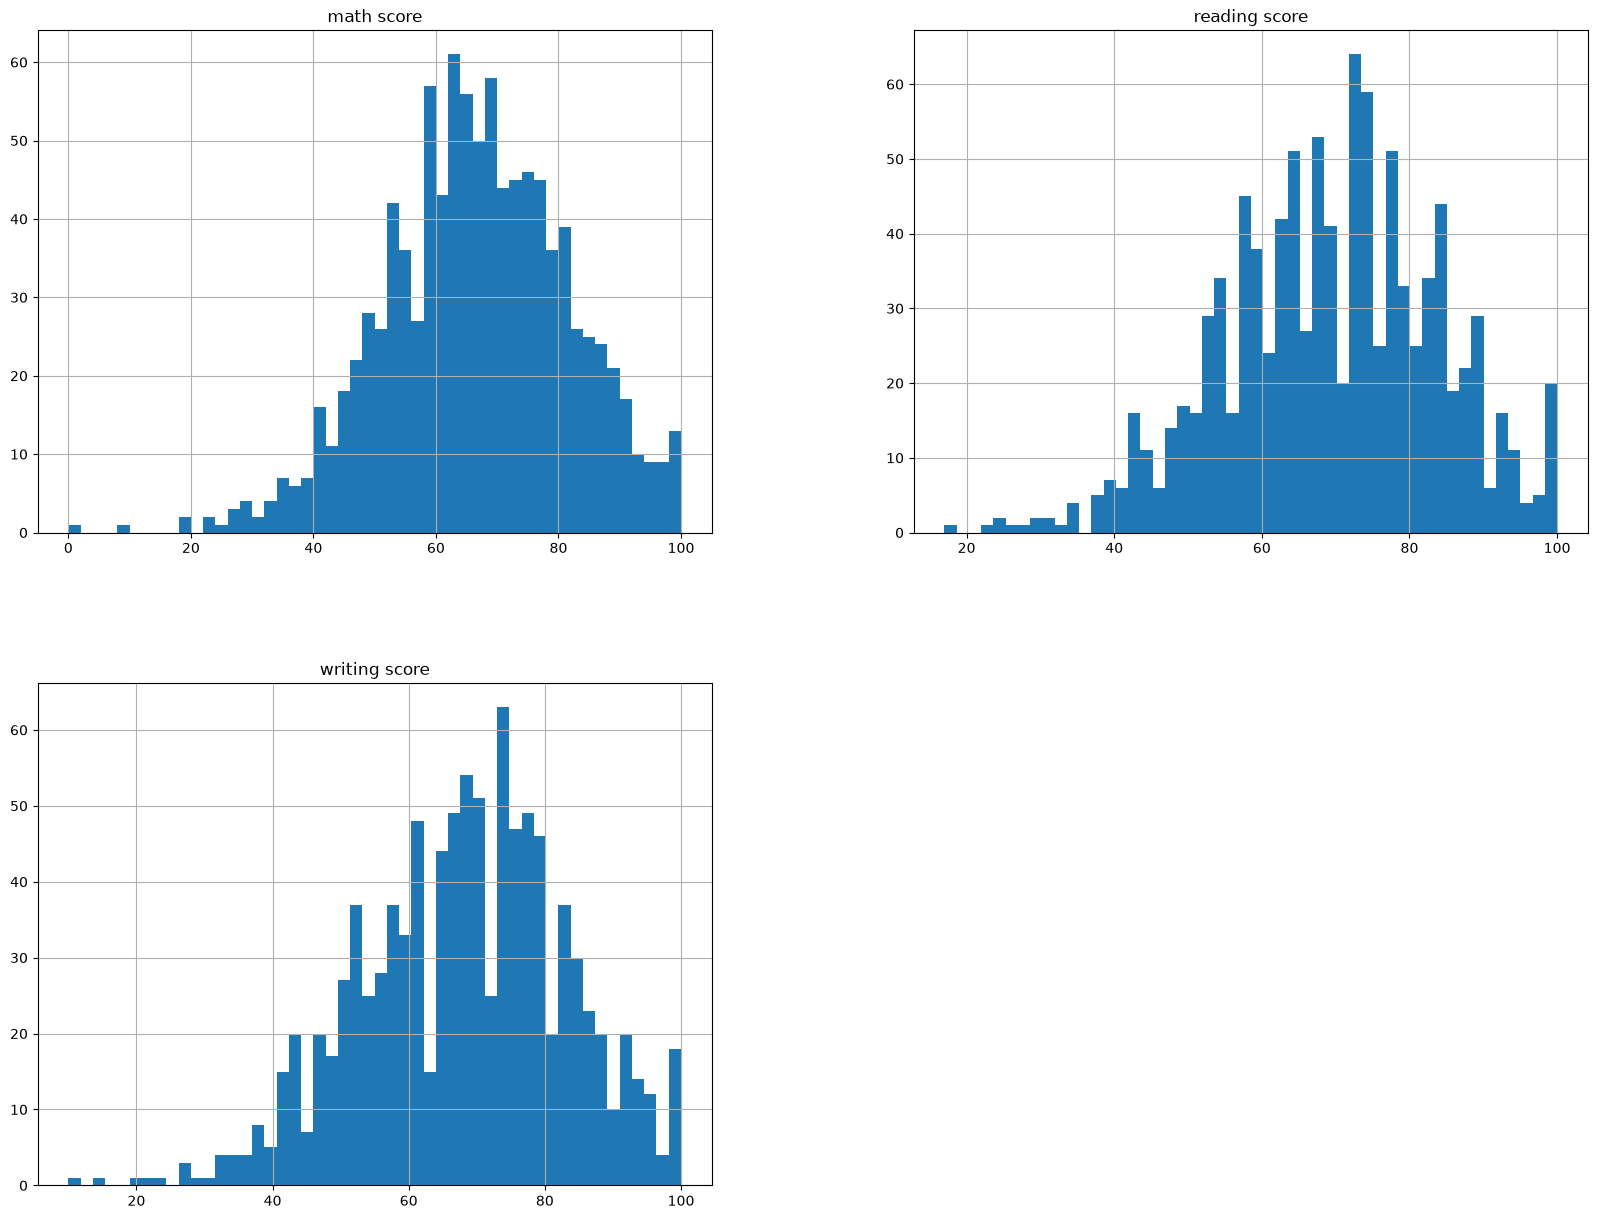

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
studat.hist(bins=50,figsize=(20,15))
plt.show()

#  Feature Engineering

To better understand overall academic performance, we create new features.

### Total Score

Total Score combines performance across all subjects:

Total Score = Math Score + Reading Score + Writing Score

### Score Categories

Students are grouped into performance categories for stratified sampling and analysis.

In [7]:
import numpy as np
studat["total_score"] = (studat["math score"] + studat["writing score"] + studat["reading score"])

studat["score_cat"] = pd.cut(studat["total_score"],bins=[0,120,180,240,300],labels=[1,2,3,4])

<Axes: >

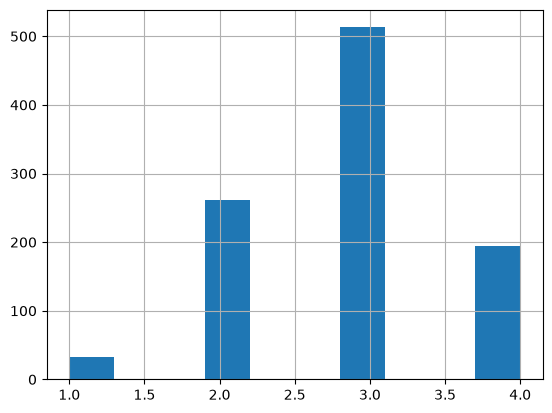

In [8]:
studat["score_cat"].hist()

##  Stratified Sampling

Instead of randomly splitting the data, stratified sampling ensures that each score category is represented proportionally in both the training and testing sets.

This helps create more reliable model evaluation.

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

split= StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(studat, studat["score_cat"]):
    strat_train_set = studat.loc[train_index]
    strat_test_set = studat.loc[test_index]

In [10]:
strat_test_set["score_cat"].value_counts()

score_cat
3    103
2     52
4     39
1      6
Name: count, dtype: int64

In [11]:
studat = strat_train_set.copy()

#  Exploratory Data Analysis

The following visualizations explore relationships between academic performance variables.

<Axes: xlabel='total_score', ylabel='math score'>

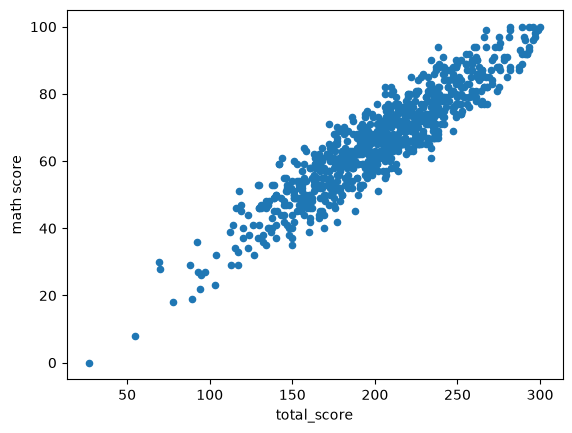

In [12]:
studat.plot(kind="scatter",x="total_score",y="math score")

<Axes: xlabel='total_score', ylabel='math score'>

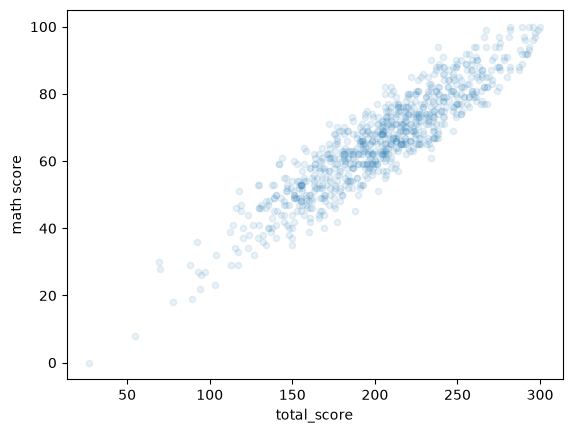

In [13]:
studat.plot(kind="scatter",x="total_score",y="math score",alpha=0.1)

## Relationship Between Reading and Writing Scores

Reading and writing abilities are often strongly related.

Scatter plots help visualize the strength of this relationship.

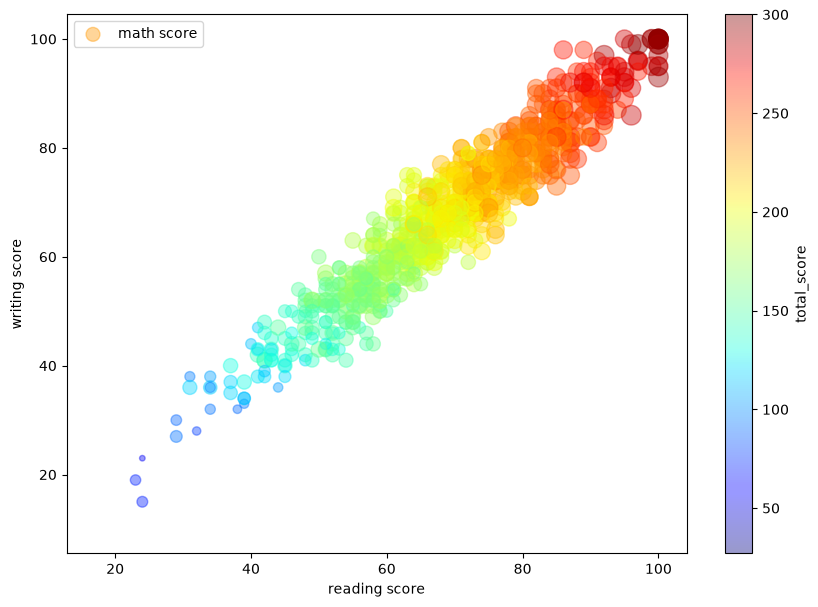

In [14]:
studat.plot(kind="scatter",
            x="reading score",
            y="writing score",
            alpha=0.4,
            s=studat["math score"] * 2,
            label = "math score",
            figsize=(10,7),
            c = "total_score",
            cmap = plt.get_cmap("jet"),
            colorbar=True
           )
plt.legend()

<Axes: xlabel='parental level of education', ylabel='total_score'>

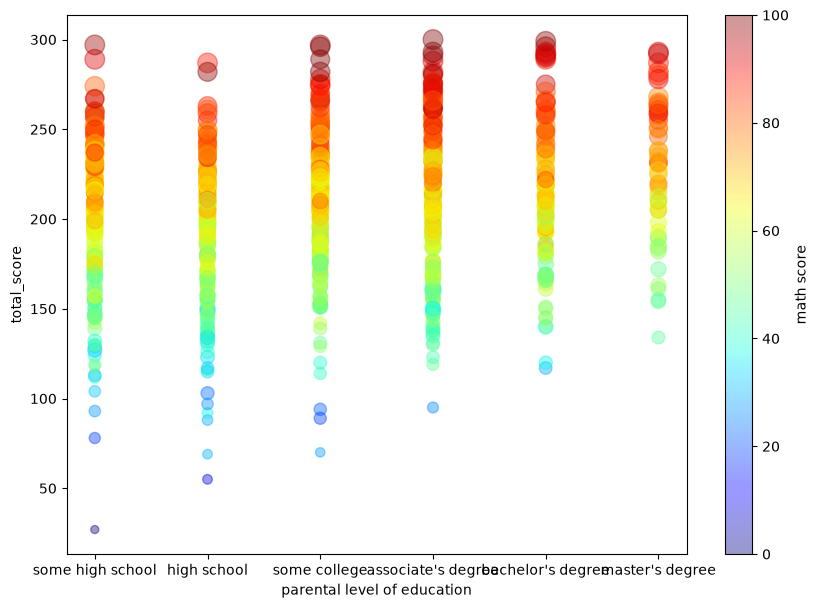

In [15]:
studat.plot(kind="scatter",
            x="parental level of education",
            y="total_score",
            alpha=0.4,
            s=studat["reading score"] * 2,
            c="math score",
            cmap = plt.get_cmap("jet"),
            figsize=(10,7),
            colorbar=True
           )

## Enhanced Scatter Plot Visualization

This visualization adds:

- Bubble Size → Total Score
- Color → Math Score

allowing multiple dimensions of student performance to be visualized simultaneously.

<Axes: xlabel='reading score', ylabel='writing score'>

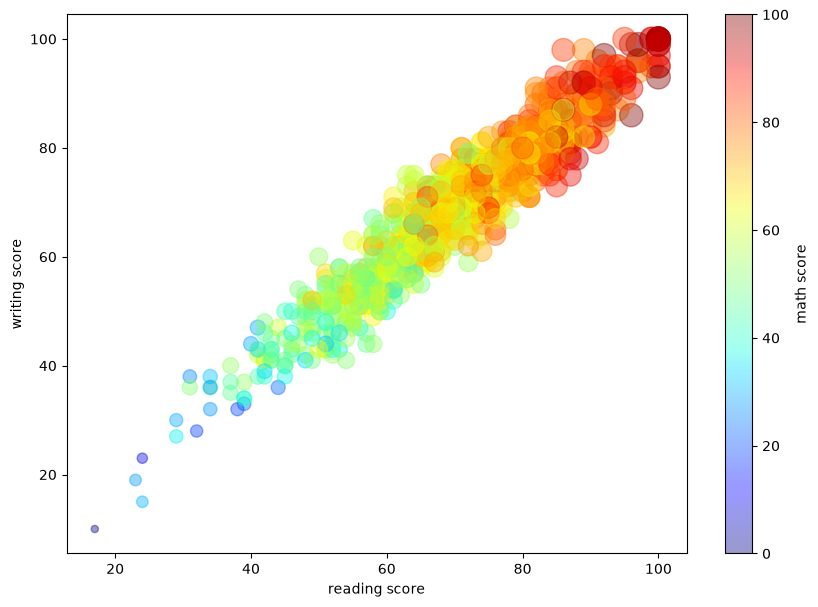

In [16]:
studat.plot(
    kind="scatter",
    x="reading score",
    y="writing score",
    alpha=0.4,
    s=studat["total_score"],
    c="math score",
    cmap=plt.get_cmap("jet"),
    figsize=(10,7),
    colorbar=True
)

##  Correlation Analysis

Correlation analysis helps identify which variables have the strongest relationship with student performance.

Highly correlated features often contain valuable predictive information.

In [17]:
corr_matrix = studat.corr(numeric_only=True)
corr_matrix["total_score"].sort_values(ascending=False)

total_score      1.000000
reading score    0.971652
writing score    0.965930
math score       0.919848
Name: total_score, dtype: float64

## Scatter Matrix

A scatter matrix allows pairwise comparison between numerical variables and helps reveal trends that may not be visible in individual plots.

array([[<Axes: xlabel='math score', ylabel='math score'>,
        <Axes: xlabel='reading score', ylabel='math score'>,
        <Axes: xlabel='writing score', ylabel='math score'>,
        <Axes: xlabel='total_score', ylabel='math score'>],
       [<Axes: xlabel='math score', ylabel='reading score'>,
        <Axes: xlabel='reading score', ylabel='reading score'>,
        <Axes: xlabel='writing score', ylabel='reading score'>,
        <Axes: xlabel='total_score', ylabel='reading score'>],
       [<Axes: xlabel='math score', ylabel='writing score'>,
        <Axes: xlabel='reading score', ylabel='writing score'>,
        <Axes: xlabel='writing score', ylabel='writing score'>,
        <Axes: xlabel='total_score', ylabel='writing score'>],
       [<Axes: xlabel='math score', ylabel='total_score'>,
        <Axes: xlabel='reading score', ylabel='total_score'>,
        <Axes: xlabel='writing score', ylabel='total_score'>,
        <Axes: xlabel='total_score', ylabel='total_score'>]], dtype=objec

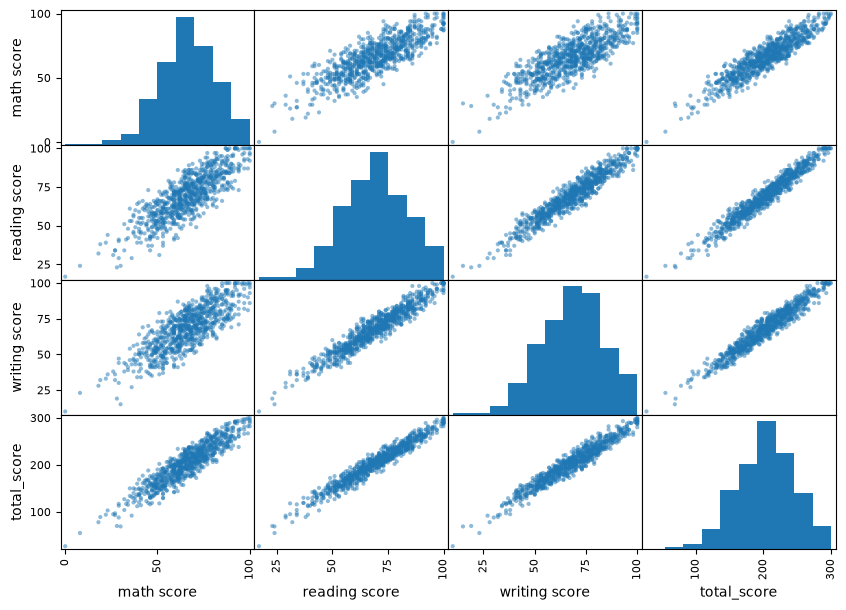

In [18]:
from pandas.plotting import scatter_matrix
scatter_matrix(studat,figsize=(10,7))

#  Data Preprocessing

Machine learning models require clean and properly formatted data.

This section builds a reusable preprocessing pipeline.

### Missing Values

The dataset contains no missing values.

However, a SimpleImputer is still included because:

- Future datasets may contain missing values
- Pipelines should remain production-ready
- It follows best practices in machine learning workflows

In [19]:
studat.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 278 to 181
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       800 non-null    str     
 1   race/ethnicity               800 non-null    str     
 2   parental level of education  800 non-null    str     
 3   lunch                        800 non-null    str     
 4   test preparation course      800 non-null    str     
 5   math score                   800 non-null    int64   
 6   reading score                800 non-null    int64   
 7   writing score                800 non-null    int64   
 8   total_score                  800 non-null    int64   
 9   score_cat                    800 non-null    category
dtypes: category(1), int64(4), str(5)
memory usage: 63.3 KB


## Building the Preprocessing Pipeline

The pipeline performs:

### Numerical Features
- Median Imputation
- Standard Scaling

### Categorical Features
- One-Hot Encoding

The ColumnTransformer combines both preprocessing strategies into a single workflow.

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

num_cols = [
    "reading score",
    "writing score"
]

cat_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ("cat",OneHotEncoder())
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

studat_prep = full_pipeline.fit_transform(studat)

#  Linear Regression Model

Linear Regression serves as the baseline model.

The objective is to predict:

**Math Score**

using student demographic and academic features.

In [35]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
X = studat.drop("math score",axis = 1)
y = studat["math score"]

In [36]:
studat_prep.shape

(800, 19)

In [37]:
X_prep = full_pipeline.fit_transform(X)
lin_reg.fit(X_prep,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[ 4.12,10.43,-6.55,..., 1.69,-1.71, 1.71]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,65.27
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](19,)","[40.89,19.97,19.6 ,..., 0. , 0. , 0. ]"


In [39]:
predictions = lin_reg.predict(X_prep)

##  Model Evaluation

Root Mean Squared Error (RMSE) measures the average prediction error.

Lower RMSE values indicate better predictive performance.

In [41]:
from sklearn.metrics import mean_squared_error
import numpy as np
lin_mse = mean_squared_error(y,predictions)
lin_rmse = np.sqrt(lin_mse)
print("RMSE: ",lin_rmse)

RMSE:  5.233868597433999


#  Decision Tree Regressor

Decision Trees can capture nonlinear relationships.

However, they are prone to overfitting if not evaluated carefully.

In [43]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_prep,y)
tree_predictions = tree_reg.predict(X_prep)
tree_rmse = np.sqrt(mean_squared_error(y,tree_predictions))

print("RMSE: ",tree_rmse)

RMSE:  0.1346291201783626


In [45]:
print(X.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'reading score', 'writing score',
       'total_score', 'score_cat'],
      dtype='str')


In [46]:
studat[['math score','total_score']].corr()

,math score,total_score
math score,1.000000,0.919848
total_score,0.919848,1.000000


In [47]:
feature_names = X.columns

for name, coef in zip(feature_names, lin_reg.coef_):
    print(name, coef)

gender 4.118168059477577
race/ethnicity 10.428310624410901
parental level of education -6.547703771818908
lunch 6.547703771818912
test preparation course -1.133949798671324
reading score -0.48459517451810974
writing score -1.3249873068627467
total_score -0.9268224674951198
score_cat 3.8703547475472937


#  Train-Test Split

To obtain an unbiased estimate of model performance, the data is divided into:

- Training Set (80%)
- Test Set (20%)

The model is trained on one portion and evaluated on unseen data.

In [49]:
from sklearn.model_selection import train_test_split

X = studat.drop("math score", axis=1)
y = studat["math score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [50]:
X_train_prep = full_pipeline.fit_transform(X_train)
X_test_prep = full_pipeline.transform(X_test)

lin_reg.fit(X_train_prep, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[ 3.4 ,10.85,-6.5 ,..., 1.72,-1.81, 1.81]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,65.11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](19,)","[36.45,18.21,17.26,..., 0. , 0. , 0. ]"


In [51]:
from sklearn.metrics import mean_squared_error
import numpy as np

preds = lin_reg.predict(X_test_prep)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("Test RMSE:", rmse)

Test RMSE: 5.359496805512577


#  Cross Validation

Cross Validation provides a more reliable estimate of model performance.

Instead of relying on a single train-test split, the model is evaluated across multiple folds of the dataset.

This helps detect overfitting and improves confidence in the reported results.

In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lin_reg,
    X_train_prep,
    y_train,
    scoring="neg_mean_squared_error",
    cv=5
)

rmse_scores = np.sqrt(-scores)

print(rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

[5.28979825 5.68597155 5.14499678 4.99129884 5.42451038]
Mean RMSE: 5.307315161143213


#  Random Forest Regressor

Random Forest is an ensemble learning method that combines multiple decision trees.

The goal is to determine whether a more complex model can outperform Linear Regression.

In [53]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()

#  Hyperparameter Tuning with GridSearchCV

Grid Search systematically evaluates different combinations of hyperparameters.

Parameters explored:

- n_estimators
- max_features
- bootstrap

The best combination is selected using 5-fold cross-validation.

In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'n_estimators':[10, 50, 100],
        'max_features':[2, 4, 6]
    },
    {
        'bootstrap':[False],
        'n_estimators':[10, 50],
        'max_features':[2, 4]
    }
]

grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score = True,
    n_jobs = -1
)

In [56]:
grid_search.fit(X_train_prep,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [10, 50, ...]}, {'bootstrap': [False], 'max_features': [2, 4], 'n_estimators': [10, 50]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be 

## Best Hyperparameters

After evaluating all candidate models, GridSearchCV identifies the parameter combination that minimizes validation error.

In [58]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 100}

In [59]:
import numpy as np
best_rmse = np.sqrt(-grid_search.best_score_)
print(best_rmse)

6.061839990830817


## Final Random Forest Evaluation

The best model obtained from Grid Search is evaluated on the test set to measure its performance on previously unseen data.

In [61]:
best_model = grid_search.best_estimator_
preds = best_model.predict(X_test_prep)
rmse = np.sqrt(mean_squared_error(y_test,preds))
print("Test RMSE: ",rmse)

Test RMSE:  6.017084176202535


#  Model Persistence

The best-performing model is saved using Joblib.

Saving the model allows future predictions without retraining.

In [64]:
import joblib
joblib.dump(best_model,"best_model.pkl")

['best_model.pkl']

#  Final Results

| Model | Performance |
|---------|---------|
| Linear Regression | RMSE ≈ 5.36 |
| Random Forest (Tuned) | RMSE ≈ 6.02 |

## Conclusion

Linear Regression achieved the best overall performance on this dataset.

Although Random Forest models were evaluated and tuned using GridSearchCV, they did not outperform the simpler linear model.

This suggests that the relationships between the predictor variables and mathematics performance are largely linear.

## Key Concepts Demonstrated

• Exploratory Data Analysis

• Feature Engineering

• Correlation Analysis

• Data Visualization

• Preprocessing Pipelines

• One-Hot Encoding

• Feature Scaling

• Linear Regression

• Random Forest Regression

• Cross Validation

• Hyperparameter Tuning

• Model Persistence